In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split

## Data preparation

- Read dataset
- Use float data types
- Drop NaN values
- Fix smokes attribute
- Use boolean to categorical attributes
- Scale the numerical values between 0 and 1
- Split the dataset to train-test-valid datasets

In [2]:
PATH = "./data/fitness_dataset.csv"
df = pd.read_csv(PATH)

In [3]:
df.dtypes

age                    int64
height_cm              int64
weight_kg              int64
heart_rate           float64
blood_pressure       float64
sleep_hours          float64
nutrition_quality    float64
activity_index       float64
smokes                object
gender                object
is_fit                 int64
dtype: object

In [4]:
input_columns = [
    "age",
    "height_cm",
    "weight_kg",
    "heart_rate",
    "blood_pressure",
    "sleep_hours",
    "nutrition_quality",
    "activity_index",
    "smokes",
    "gender",
]

numerical_columns = [
    "age",
    "height_cm",
    "weight_kg",
    "heart_rate",
    "blood_pressure",
    "sleep_hours",
    "nutrition_quality",
    "activity_index",
]
categorical_columns = ["smokes", "gender"]

In [5]:
df = df[df.notna().all(axis=1)]

In [6]:
df_input = df[input_columns]
df_output = df["is_fit"]

In [7]:
df_input.loc[:, "smokes"] = df_input["smokes"].map({"yes": True, "no": False, "0": False, "1": True})

In [8]:
df_input.loc[:, "gender"] = df_input["gender"].map({"M": 0, "F": 1})

In [9]:
df_input.head()

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender
1,69,186,95,60.8,114.8,7.5,8.77,3.19,False,1
3,32,189,83,60.2,130.1,7.0,6.18,3.68,False,0
4,60,175,99,58.1,115.8,8.0,9.95,4.83,True,1
5,25,172,85,81.2,119.2,7.7,7.35,4.08,True,0
6,78,193,83,79.6,132.5,7.4,2.16,3.42,True,1


In [10]:
df_input.describe()

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index
count,1840.000000,1840.00000,1840.000000,1840.000000,1840.000000,1840.000000,1840.000000,1840.000000
mean,49.135870,174.50163,83.789130,70.196576,119.886304,7.513315,5.023924,2.998114
std,17.950116,14.40100,25.776407,11.783745,14.499130,1.502031,2.865756,1.132126
min,18.000000,150.00000,30.000000,45.000000,90.000000,4.000000,0.000000,1.000000
25%,34.000000,162.00000,64.000000,62.100000,109.800000,6.500000,2.547500,2.047500
50%,49.000000,174.00000,83.000000,70.100000,119.800000,7.500000,5.050000,2.990000
75%,65.000000,187.00000,102.000000,78.300000,129.800000,8.600000,7.462500,3.930000
max,79.000000,199.00000,250.000000,118.600000,171.200000,12.000000,10.000000,4.990000


In [11]:
df_input[numerical_columns] = df_input[numerical_columns].astype('float64')
df_input[categorical_columns] = df_input[categorical_columns].astype('boolean')

/tmp/ipykernel_41291/2196268274.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_input[numerical_columns] = df_input[numerical_columns].astype('float64')
/tmp/ipykernel_41291/2196268274.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_input[categorical_columns] = df_input[categorical_columns].astype('boolean')


In [12]:
df_input.loc[:, numerical_columns] = df_input[numerical_columns].apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)

In [13]:
df_input.head()

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender
1,0.836066,0.734694,0.295455,0.214674,0.305419,0.4375,0.877,0.548872,False,True
3,0.229508,0.795918,0.240909,0.206522,0.493842,0.3750,0.618,0.671679,False,False
4,0.688525,0.510204,0.313636,0.177989,0.317734,0.5000,0.995,0.959900,True,True
5,0.114754,0.448980,0.250000,0.491848,0.359606,0.4625,0.735,0.771930,True,False
6,0.983607,0.877551,0.240909,0.470109,0.523399,0.4250,0.216,0.606516,True,True


In [14]:
X_train, X_test, y_train, y_test = train_test_split(df_input, df_output, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

## Model Selection and Description

This section defines the machine learning models used for classification. The models include **Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost**. These models are chosen for their diverse approaches to handling classification tasks and their ability to capture different patterns in the data.


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [16]:
models = [
    LogisticRegression(random_state=42),
    DecisionTreeClassifier(max_depth=5, random_state=42),
    RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    XGBClassifier(n_estimators=50, max_depth=4, random_state=42),
]

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

metrics = {}

for model in models:
    model_name = model.__class__.__name__
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    
    metrics[model_name] = {
        "accuracy": accuracy_score(y_valid, y_pred),
        "precision": precision_score(y_valid, y_pred),
        "recall": recall_score(y_valid, y_pred),
        "f1_score": f1_score(y_valid, y_pred),
        "roc_auc": roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1])
    }

for model_name, model_metrics in metrics.items():
    print(f"Metrics for {model_name}:")
    for metric_name, value in model_metrics.items():
        print(f"  {metric_name}: {value:.4f}")
    print()

Metrics for LogisticRegression:
  accuracy: 0.7908
  precision: 0.7881
  recall: 0.6414
  f1_score: 0.7072
  roc_auc: 0.8747

Metrics for DecisionTreeClassifier:
  accuracy: 0.7310
  precision: 0.6597
  recall: 0.6552
  f1_score: 0.6574
  roc_auc: 0.7170

Metrics for RandomForestClassifier:
  accuracy: 0.8016
  precision: 0.8158
  recall: 0.6414
  f1_score: 0.7181
  roc_auc: 0.8520

Metrics for GradientBoostingClassifier:
  accuracy: 0.8016
  precision: 0.7903
  recall: 0.6759
  f1_score: 0.7286
  roc_auc: 0.8518

Metrics for XGBClassifier:
  accuracy: 0.8288
  precision: 0.8417
  recall: 0.6966
  f1_score: 0.7623
  roc_auc: 0.8511



## Evaluate the Best Model Based on ROC-AUC

The code identifies the best model based on the highest ROC-AUC score from the `metrics` dictionary and evaluates it on the test set.

Metrics for XGBClassifier:
  Accuracy: 0.7554
  Precision: 0.7516
  Recall: 0.6886
  F1 Score: 0.7188
  ROC AUC: 0.8228


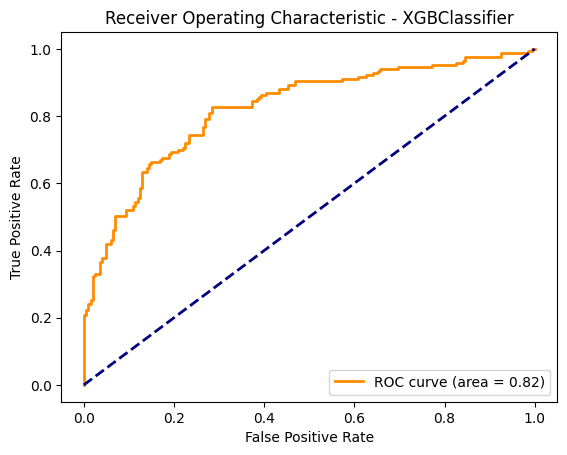

In [18]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

model = models[4]  # XGBoost
model_name = model.__class__.__name__
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]


print(f"Metrics for {model_name}:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred):.4f}")
print(f"  F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"  ROC AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}")
    


fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Receiver Operating Characteristic - {model_name}")
plt.legend(loc="lower right")
plt.show()

## Save models

In [19]:
import os
from joblib import dump

os.makedirs("./models", exist_ok=True)

for i, model in enumerate(models):
    model_name = model.__class__.__name__
    dump(model, f"./models/{model_name}.joblib")
    print(f"Saved {model_name} to ./models/{model_name}.joblib")

Saved LogisticRegression to ./models/LogisticRegression.joblib
Saved DecisionTreeClassifier to ./models/DecisionTreeClassifier.joblib
Saved RandomForestClassifier to ./models/RandomForestClassifier.joblib
Saved GradientBoostingClassifier to ./models/GradientBoostingClassifier.joblib
Saved XGBClassifier to ./models/XGBClassifier.joblib
